In [3]:
import pandas as pd

In [4]:
train_df = pd.read_csv("../dataset/train.csv")

In [5]:
test_df = pd.read_csv("../dataset/test.csv")

In [6]:
print(train_df.head())

                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival


In [8]:
print(train_df.shape)
print(test_df.shape)

(10003, 2)
(3080, 2)


In [9]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      10003 non-null  str  
 1   category  10003 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB
None


In [10]:
print(train_df.isnull().sum())

text        0
category    0
dtype: int64


In [11]:
print(train_df.duplicated().sum())

0


In [12]:
print("Number of categories:", train_df["category"].nunique())

Number of categories: 77


In [13]:
print(train_df["category"].value_counts())

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64


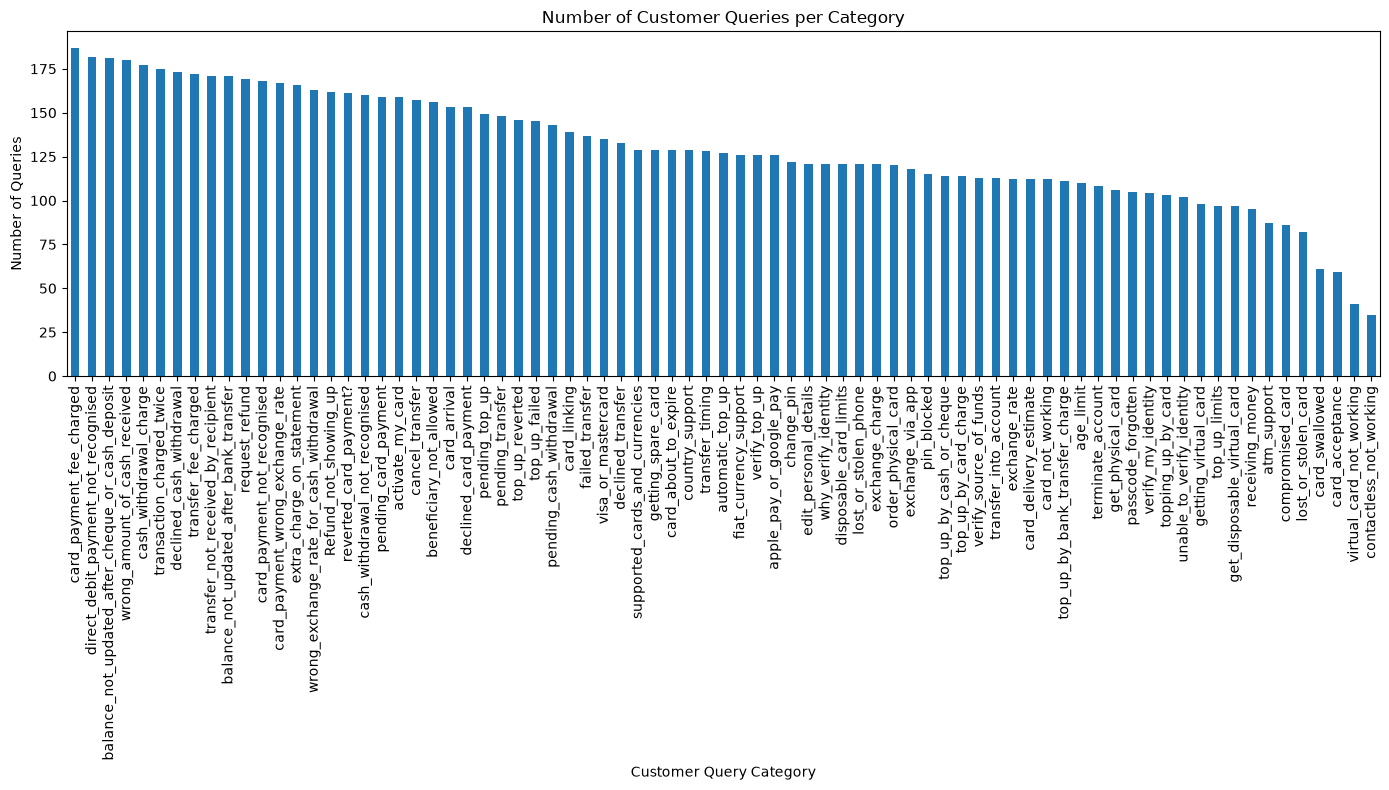

In [16]:
import matplotlib.pyplot as plt

category_counts = train_df["category"].value_counts()

plt.figure(figsize=(14, 8))
category_counts.plot(kind="bar")

plt.title("Number of Customer Queries per Category")
plt.xlabel("Customer Query Category")
plt.ylabel("Number of Queries")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [17]:
train_df["text_length"] = train_df["text"].str.len()

In [18]:
print(train_df["text_length"].describe())

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64


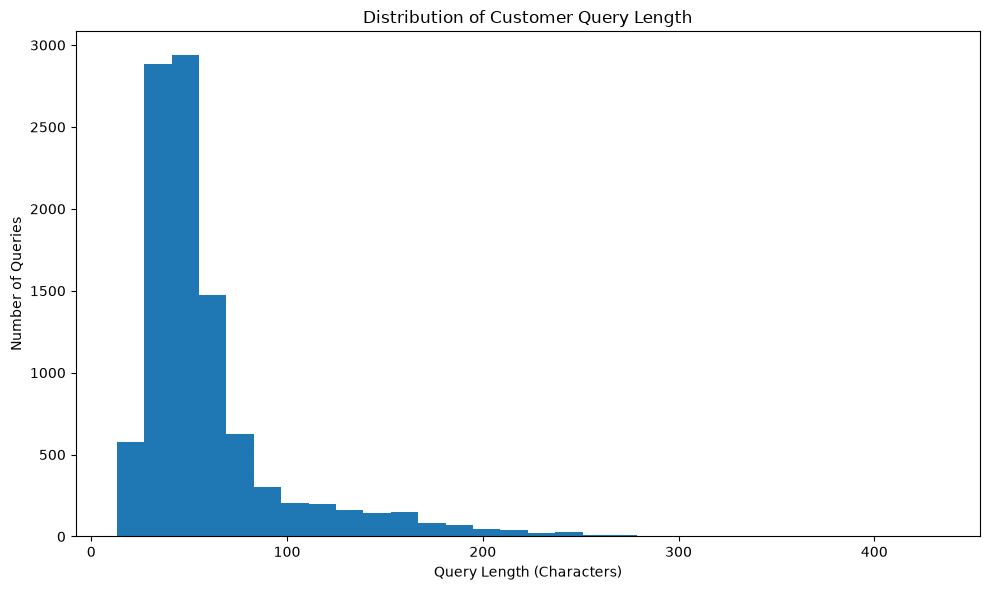

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(train_df["text_length"], bins=30)

plt.title("Distribution of Customer Query Length")
plt.xlabel("Query Length (Characters)")
plt.ylabel("Number of Queries")

plt.tight_layout()
plt.show()

In [20]:
print("Top 10 categories:")
print(train_df["category"].value_counts().head(10))

Top 10 categories:
category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: count, dtype: int64


In [21]:
print("\nBottom 10 categories:")
print(train_df["category"].value_counts().tail(10))


Bottom 10 categories:
category
top_up_limits                  97
get_disposable_virtual_card    97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: count, dtype: int64


In [22]:
train_clean = train_df.copy()
test_clean = test_df.copy()

In [23]:
print(train_clean["text"].head())
print(train_clean["text"].dtype)

0                       I am still waiting on my card?
1    What can I do if my card still hasn't arrived ...
2    I have been waiting over a week. Is the card s...
3    Can I track my card while it is in the process...
4    How do I know if I will get my card, or if it ...
Name: text, dtype: str
str


In [24]:
train_clean["text"] = train_clean["text"].str.strip()
test_clean["text"] = test_clean["text"].str.strip()

In [25]:
print(train_clean["text"].isnull().sum())
print(test_clean["text"].isnull().sum())

0
0


In [26]:
X_train = train_clean["text"]
y_train = train_clean["category"]

X_test = test_clean["text"]
y_test = test_clean["category"]

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=10000
)

In [36]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [37]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (10003, 10000)
Testing shape: (3080, 10000)


In [39]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000
)

model_lr.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [40]:
y_pred_lr = model_lr.predict(X_test_tfidf)

In [41]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8590909090909091


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.88      0.95      0.92        40
                                activate_my_card       1.00      0.95      0.97        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.86      0.80      0.83        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.63      0.78      0.70        40
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.93      0.88        40
                         beneficiary_not_allowed       0.90      0.88      0.89        40
                                 cancel_transfer       0.88      0.95      0.92        40
         

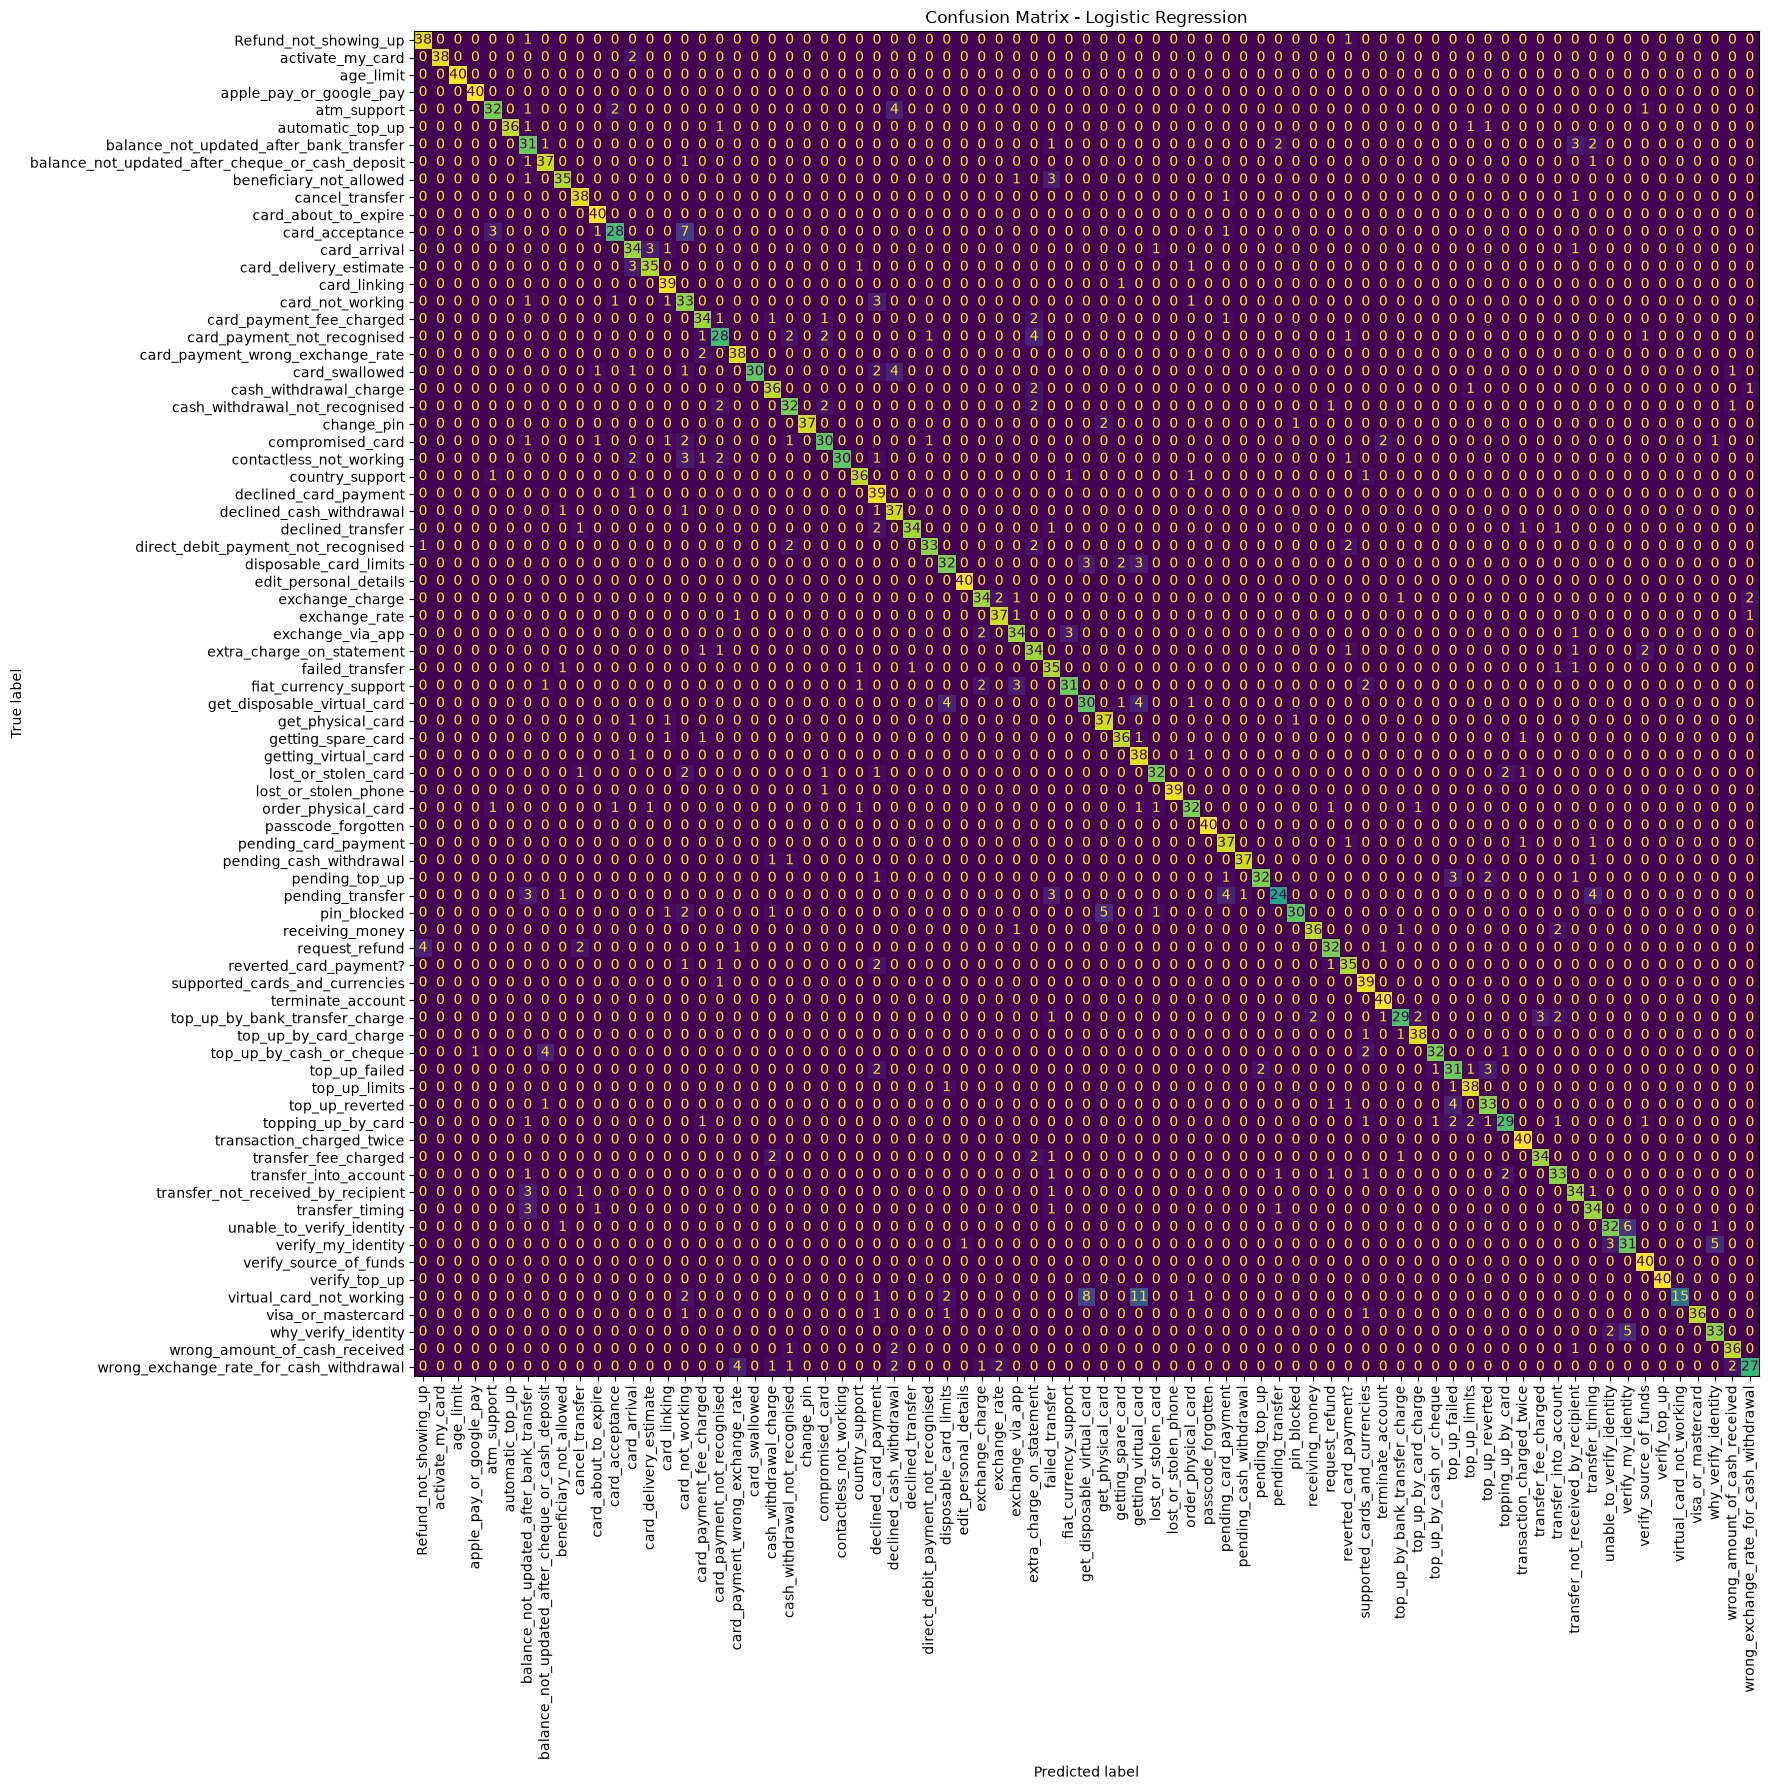

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_lr.classes_
)

fig, ax = plt.subplots(figsize=(18, 18))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [45]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train_tfidf, y_train)

print("Naive Bayes training completed!")

Naive Bayes training completed!


In [46]:
y_pred_nb = model_nb.predict(X_test_tfidf)

print("Naive Bayes predictions completed!")

Naive Bayes predictions completed!


In [47]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.7987012987012987


In [48]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Logistic Regression Weighted F1:", f1_lr)
print("Naive Bayes Weighted F1:", f1_nb)

Logistic Regression Weighted F1: 0.8581828346723873
Naive Bayes Weighted F1: 0.7852319979580049


In [49]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()

model_svm.fit(X_train_tfidf, y_train)

print("SVM training completed!")

SVM training completed!


In [50]:
y_pred_svm = model_svm.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print("SVM Accuracy:", accuracy_svm)
print("SVM Weighted F1:", f1_svm)

SVM Accuracy: 0.8899350649350649
SVM Weighted F1: 0.8899481450698299


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.95      0.95      0.95        40
                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       0.95      1.00      0.98        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.95      0.90      0.92        40
                                automatic_top_up       1.00      0.95      0.97        40
         balance_not_updated_after_bank_transfer       0.71      0.75      0.73        40
balance_not_updated_after_cheque_or_cash_deposit       0.90      0.93      0.91        40
                         beneficiary_not_allowed       0.93      0.95      0.94        40
                                 cancel_transfer       0.93      0.95      0.94        40
         

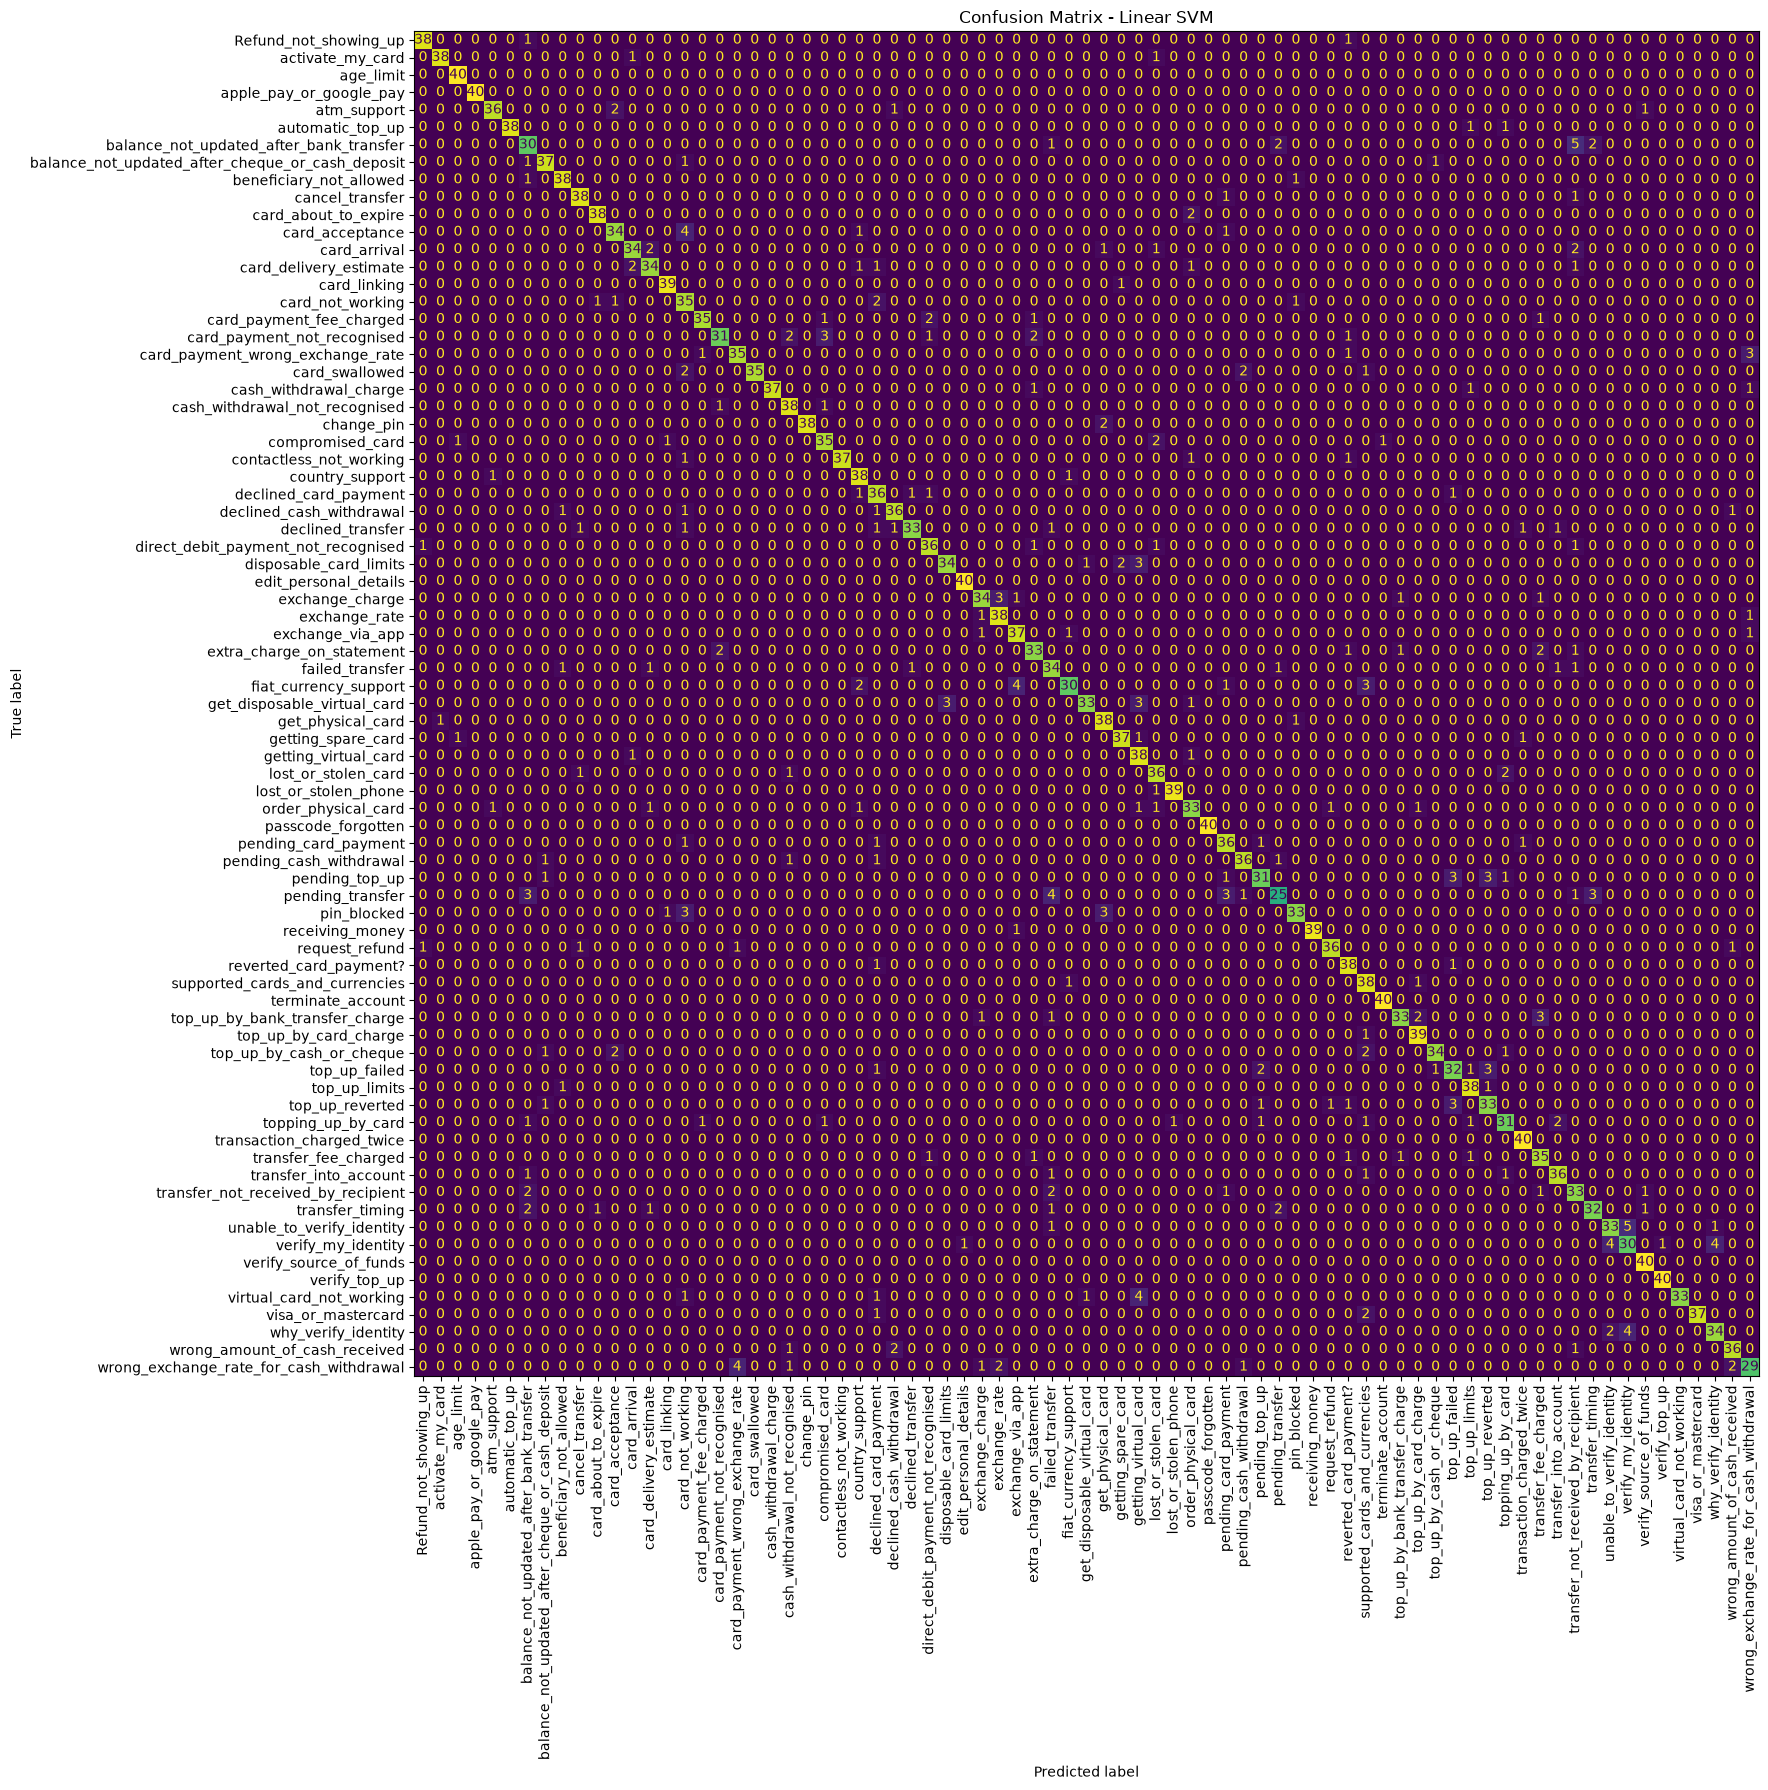

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=model_svm.classes_
)

fig, ax = plt.subplots(figsize=(18, 18))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show()

In [53]:
sample_queries = [
    "I have been waiting for my card for two weeks",
    "Someone used my card and I don't recognize the payment",
    "I forgot my PIN",
    "Why was I charged a fee for withdrawing cash?",
    "My contactless payment is not working"
]

sample_tfidf = vectorizer.transform(sample_queries)

sample_predictions = model_svm.predict(sample_tfidf)

for query, prediction in zip(sample_queries, sample_predictions):
    print("Query:", query)
    print("Predicted Category:", prediction)
    print("-" * 60)

Query: I have been waiting for my card for two weeks
Predicted Category: card_arrival
------------------------------------------------------------
Query: Someone used my card and I don't recognize the payment
Predicted Category: compromised_card
------------------------------------------------------------
Query: I forgot my PIN
Predicted Category: pin_blocked
------------------------------------------------------------
Query: Why was I charged a fee for withdrawing cash?
Predicted Category: cash_withdrawal_charge
------------------------------------------------------------
Query: My contactless payment is not working
Predicted Category: contactless_not_working
------------------------------------------------------------


In [54]:
import joblib

joblib.dump(model_svm, "../model/customer_query_svm.pkl")
joblib.dump(vectorizer, "../model/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
